In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import shap
from src.data_prep.pre_process import get_features_df
from src.models.Feature_Selection import feature_selection
from src.models.models_functions import model
from src.models.Parameters_Tuning.best_param_to_xl import get_best_params_set_xgb, get_best_param_xgb_optuna
shap.initjs()

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
data = get_features_df(rna_type = 'i')


RNAi_X_train_features = data['RNAi_X_train']
RNAi_y_train = data['RNAi_y_train']

RNAi_X_val_features = data['RNAi_X_val']
RNAi_y_val = data['RNAi_y_val']

RNAi_X_test_features = data['RNAi_X_test']
RNAi_y_test = data['RNAi_y_test']


In [3]:

RNAi_selected_features_data = feature_selection(RNAi_X_train_features, RNAi_y_train, 'i')
RNAi_selected_features = RNAi_selected_features_data['selected_features']
RNAi_FS_train = RNAi_X_train_features[RNAi_selected_features]
RNAi_FS_val = RNAi_X_val_features[RNAi_selected_features]
RNAi_FS_test = RNAi_X_test_features[RNAi_selected_features]


KeyError: "['seq_end_218_104_151'] not in index"

In [ ]:
current_dir = os.getcwd()
excel_file_path = os.path.join(os.path.dirname(os.path.dirname(current_dir)), 'xgb_RNAi_best_params.xlsx')
df = pd.read_excel(excel_file_path)
score = df['scores'].max()
params = df.iloc[df['scores'].idxmax(),:].dropna().drop('scores')
Best_param_xgb = dict(params)
Best_param_xgb['max_depth'] = int(Best_param_xgb['max_depth'])
Best_param_xgb['n_estimators'] = int(Best_param_xgb['n_estimators'])


In [ ]:
RNAi_FS_train_val_X = pd.concat([RNAi_FS_train, RNAi_FS_val])
RNAi_train_val_y = pd.concat([RNAi_y_train, RNAi_y_val])
trained_model, _, _, _ = model(RNAi_FS_train_val_X, RNAi_FS_test, RNAi_train_val_y, RNAi_y_test,
                                   'xgboost', 'iRNA', Best_param_xgb, save_plots=False)

In [6]:
## IMPORTANT - Before running it you need to either scale the data or remove the scaling from the model (which will show you the non-scaled copy number)
# from src.models.models_functions import scale
# RNAp_FS_train_val_X, RNAp_FS_test = scale(RNAp_FS_train_val_X, RNAp_FS_test)
RNAi_FS_train_val_X = pd.concat([RNAi_FS_train_val_X, RNAi_FS_test])
RNAi_train_val_y = pd.concat([RNAi_train_val_y, RNAi_y_test])

y_pred = trained_model.predict(RNAi_FS_train_val_X)
explainer = shap.Explainer(trained_model)
shap_values = explainer(RNAi_FS_train_val_X)

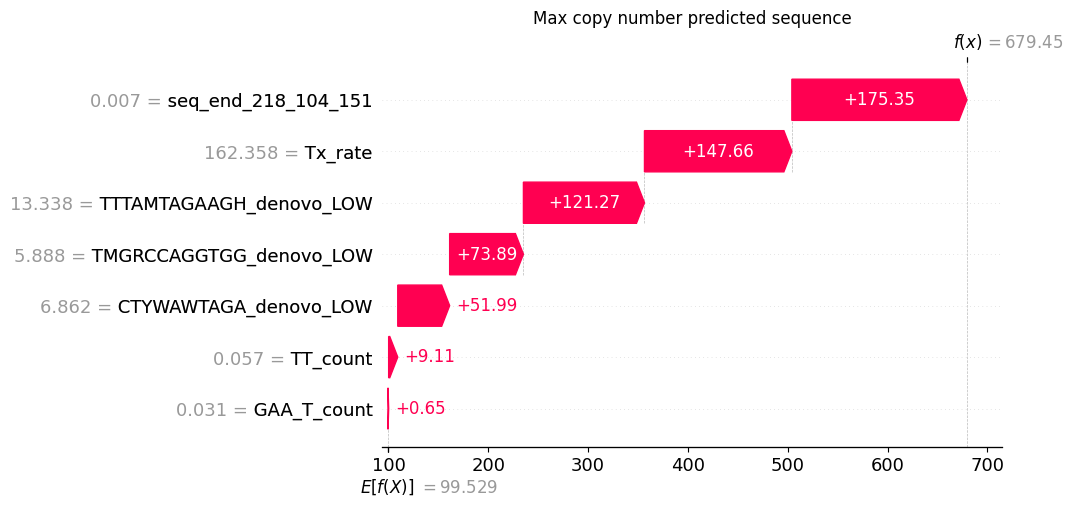

In [7]:
plt.title('Max copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmax(y_pred)], max_display=10)

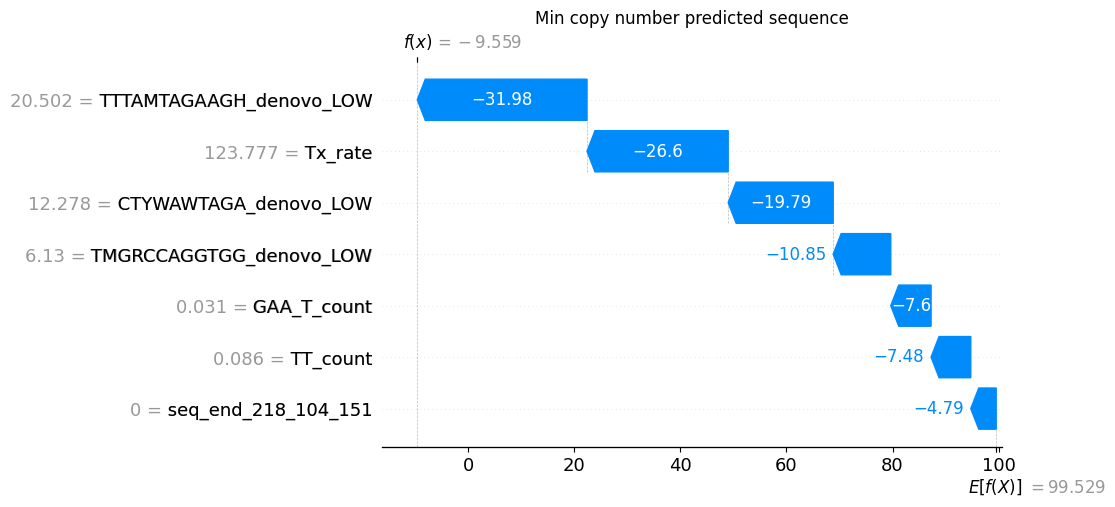

In [8]:
plt.title('Min copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmin(y_pred)], max_display=10)

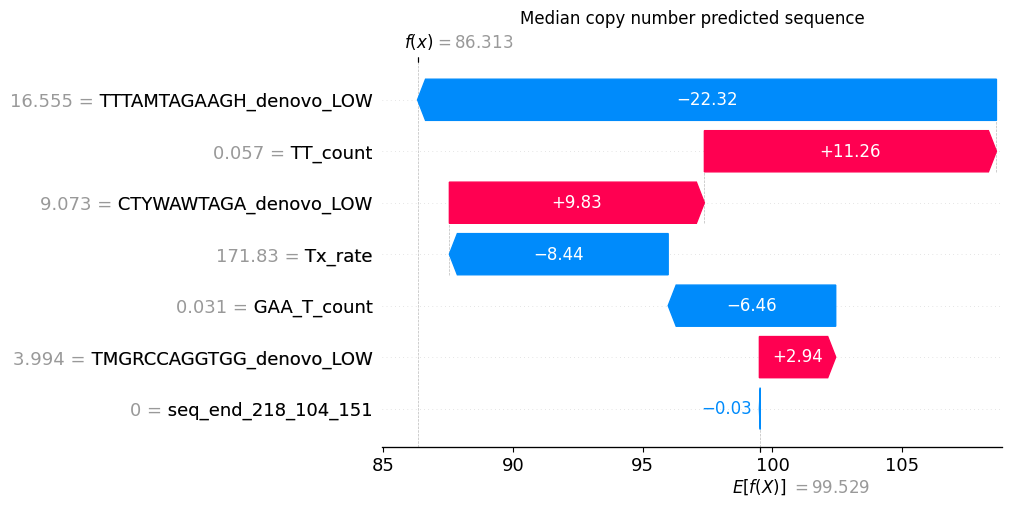

In [9]:
plt.title('Median copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argsort(y_pred)[len(y_pred)//2]],max_display=10)


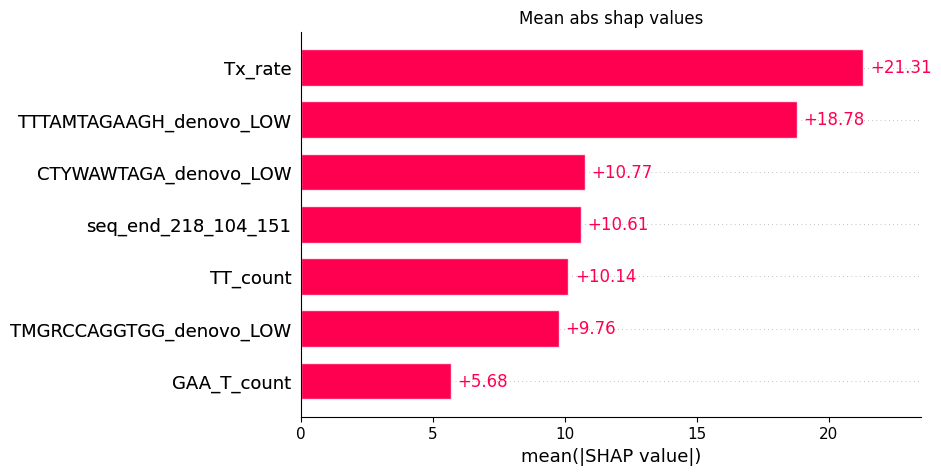

In [10]:
plot = shap.force_plot(explainer.expected_value, shap_values.values, RNAi_FS_train_val_X, show=False)
shap.save_html("shap_force_plot_RNAi.htm", plot)
plt.title('Mean abs shap values')
shap.plots.bar(shap_values)


Free Energy dG total

In [11]:
RNA_X = pd.concat([RNAi_X_train_features, RNAi_X_val_features, RNAi_X_test_features])
RNA_y = pd.concat([RNAi_y_train, RNAi_y_val, RNAi_y_test])
data = pd.concat([RNA_X['Tx_rate'], RNA_y],axis=1)
copy_number_mean = data['Copy Number'].mean()
copy_number_mean

99.37191832810866

Text(0, 0.5, 'Copy number')

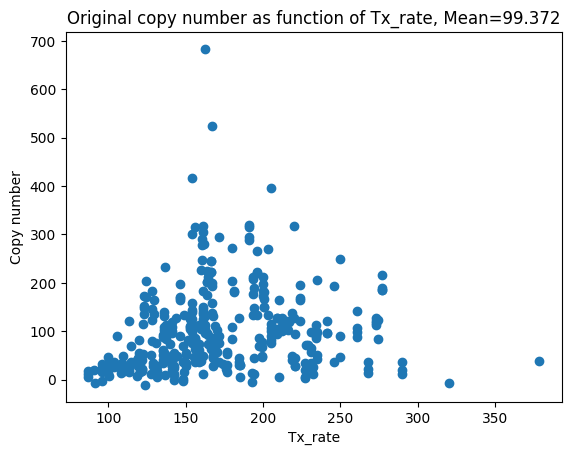

In [12]:
plt.scatter(data['Tx_rate'], data['Copy Number'])
plt.title(f'Original copy number as function of Tx_rate, Mean={copy_number_mean:.3f}')
plt.xlabel('Tx_rate')
plt.ylabel('Copy number')

In [18]:
## Empirical PV

PCN_TH = 200

above_TH = data.loc[data['Copy Number']>PCN_TH]
Tx_in_range_above_TH = above_TH[above_TH['Tx_rate'].between(150, 220)]

n_above_TH = above_TH.shape[0]
n_in_range_above_TH = Tx_in_range_above_TH.shape[0]
print(f'There are {n_above_TH} sequences above the PCN threshold: {PCN_TH}.')
print(f'There are {n_in_range_above_TH} sequences above the PCN threshold, that are in the Tx_rate range of [155,212].')

There are 42 sequences above the PCN threshold: 200.
There are 36 sequences above the PCN threshold, that are in the Tx_rate range of [155,212].


In [19]:
num_of_randomizations = 10000
null_counter = 0
for i in range(num_of_randomizations):
    random_sample = data.sample(n_above_TH)
    random_above_TH = random_sample.loc[random_sample['Copy Number']>PCN_TH]
    random_tx_in_range_above_TH = random_above_TH[random_above_TH['Tx_rate'].between(150, 220)]
    random_n_in_range_above_TH = random_tx_in_range_above_TH.shape[0]
    if random_n_in_range_above_TH >= n_in_range_above_TH:
        null_counter +=1
enrichment_pv = null_counter/num_of_randomizations
print(f'Empirical Enrichment pv = {enrichment_pv}')

Empirical Enrichment pv = 0.0


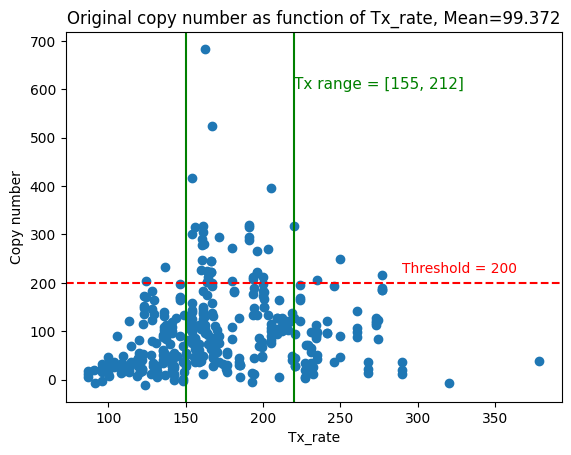

In [28]:
plt.scatter(data['Tx_rate'], data['Copy Number'])
plt.title(f'Original copy number as function of Tx_rate, Mean={copy_number_mean:.3f}')
plt.xlabel('Tx_rate')
plt.ylabel('Copy number')
plt.axhline(PCN_TH, c='r', linestyle='--')
plt.axvline(150, c='g')
plt.axvline(220, c='g')
plt.text(290, 220, f'Threshold = {PCN_TH}', c='r')
plt.text(220, 600, 'Tx range = [155, 212]', c='g', fontsize=11)

n_left = data.loc[data['Tx_rate'] <= 150].shape[0]
n_right = data.loc[data['Tx_rate'] >= 220].shape[0]
n_mid = data.shape[0] - n_left - n_right

# n_left_above = above_TH.loc[above_TH['Tx_rate'] <= 155].shape[0]
# n_right_above = above_TH.loc[above_TH['Tx_rate'] >= 212].shape[0]
# n_mid_above = above_TH[above_TH['Tx_rate'].between(155, 212)].shape[0]
#
# plt.text(-4.4, 260, f'{np.round(100*(n_left_above/n_left))}% above TH', c='b')
# plt.text(-2.3, 260, f'{np.round(100*(n_right_above/n_right))}% above TH', c='b')
# plt.text(-3.1, 800, f'{np.round(100*(n_mid_above/n_mid))}% above TH', c='b')


0.004801920768307323

Text(0, 0.5, 'Copy Number')

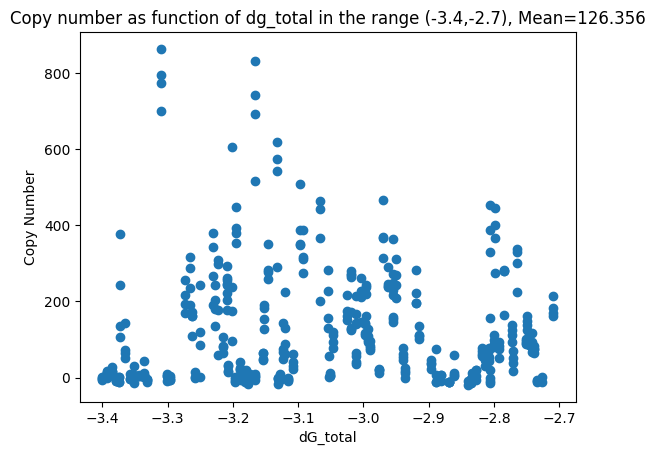

In [16]:
data_dg = data[data['dG_total'].between(-3.4, -2.7)]
plt.scatter(data_dg['dG_total'],data_dg['Copy Number'])
mean_copy_dg = data_dg['Copy Number'].mean()
plt.title(f'Copy number as function of dg_total in the range (-3.4,-2.7), Mean={mean_copy_dg:.3f}')
plt.xlabel('dG_total')
plt.ylabel('Copy Number')

In [17]:
## Analytical PV
import scipy.stats as stats
#hypergeometric distribution
#M- number of sequences #708
#N- number of sequences in the range (-3.4,-2.7) of dG_total #351
#n- number of sequences with high copy number (above 150) #121
#x- number of sequences with high copy number (above 150) in the range #115
M = data.shape[0]
N = data_dg.shape[0]
data_above_150 = data[data['Copy Number']>150]
n = data_above_150.shape[0]
data_dg_above_150 = data_dg[data_dg['Copy Number']>150]
x = data_dg_above_150.shape[0]

In [18]:
#p-value 0, significant
pv=1-stats.hypergeom.cdf(x-1,M,n,N)
print(f'Analytical enrichment pv = {pv}')

Analytical enrichment pv = 0.0
